In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import cns
import numpy as np
import matplotlib.pyplot as plt
from cns.data_utils import save_doc_fig

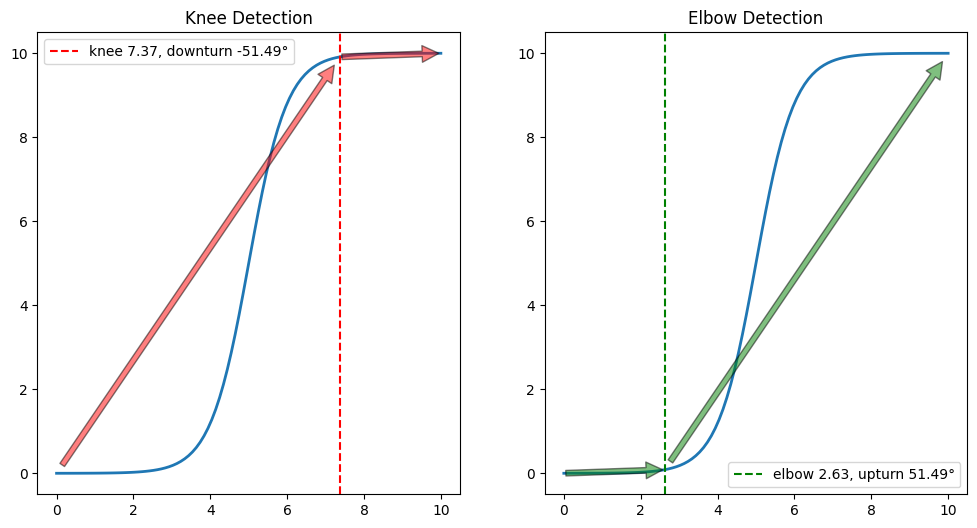

In [3]:
def logistic(x, L=1, k=1, x0=0):
    return L / (1 + np.exp(-k * (x - x0)))

# Generate points for the x-axis
test_x = np.linspace(0, 10, 100)
# Calculate the corresponding y-values using the logistic function
y_up = logistic(test_x, L=10, k=2, x0=5)

# Find knee and elbow points
knee, knee_val = cns.find_knee(test_x, y_up, True)
elbow, elbow_val = cns.find_knee(test_x, y_up, False)

# Create a figure with two subplots side by side
configs = [
    {
        'title': "Knee Detection",
        'line_color': 'r',
        'label': f'knee {test_x[knee]:.2f}, downturn {knee_val:.2f}°',
        'point': knee,
        'point_val': knee_val
    },
    {
        'title': "Elbow Detection",
        'line_color': 'g',
        'label': f'elbow {test_x[elbow]:.2f}, upturn {elbow_val:.2f}°',
        'point': elbow,
        'point_val': elbow_val
    }
]

# Plot data and annotations
arrow_alpha = 0.5
arrow_shrink = 0.02
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i, plot in enumerate(configs):
    ax = axs[i]
    point = plot['point']
    line_color = plot['line_color']
    label = plot['label']
    
    ax.plot(test_x, y_up, linewidth=2)
    ax.axvline(x=test_x[point], color=line_color, linestyle='--', label=label)
    ax.annotate('', xy=(test_x[point], y_up[point]), xytext=(test_x[0], y_up[0]),
                arrowprops=dict(facecolor=line_color, alpha=arrow_alpha, shrink=arrow_shrink))
    ax.annotate('', xy=(test_x[-1], y_up[-1]), xytext=(test_x[point], y_up[point]),
                arrowprops=dict(facecolor=line_color, alpha=arrow_alpha, shrink=arrow_shrink))
    ax.legend()
    ax.set_title(plot['title'])

save_doc_fig('knee_detection')

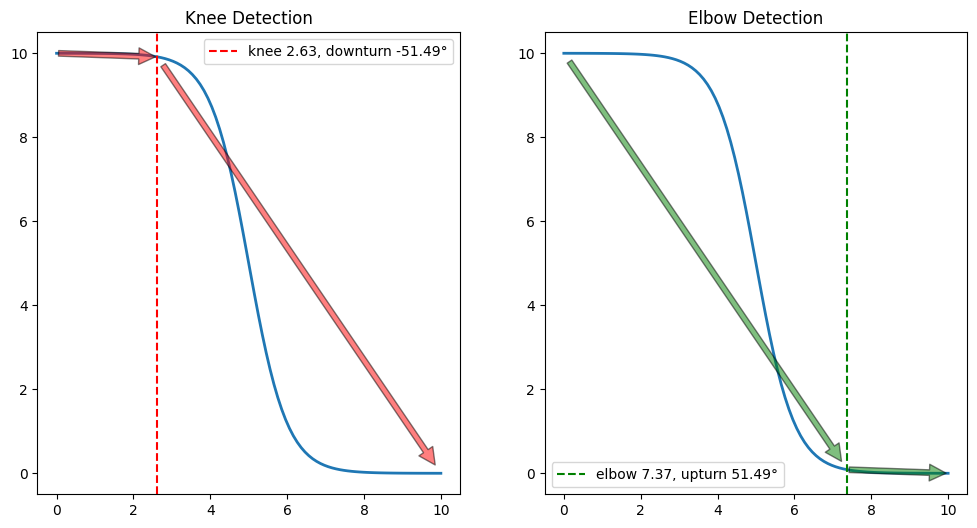

In [4]:
# Calculate the corresponding y-values using the logistic function
y_down = 10 - y_up

# Find knee and elbow points
knee, knee_val = cns.find_knee(test_x, y_down, True)
elbow, elbow_val = cns.find_knee(test_x, y_down, False)

# Create a figure with two subplots side by side
configs = [
    {
        'title': "Knee Detection",
        'line_color': 'r',
        'label': f'knee {test_x[knee]:.2f}, downturn {knee_val:.2f}°',
        'point': knee,
        'point_val': knee_val
    },
    {
        'title': "Elbow Detection",
        'line_color': 'g',
        'label': f'elbow {test_x[elbow]:.2f}, upturn {elbow_val:.2f}°',
        'point': elbow,
        'point_val': elbow_val
    }
]

# Plot data and annotations
arrow_alpha = 0.5
arrow_shrink = 0.02
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i, plot in enumerate(configs):
    ax = axs[i]
    point = plot['point']
    line_color = plot['line_color']
    label = plot['label']
    
    ax.plot(test_x, y_down, linewidth=2)
    ax.axvline(x=test_x[point], color=line_color, linestyle='--', label=label)
    ax.annotate('', xy=(test_x[point], y_down[point]), xytext=(test_x[0], y_down[0]),
                arrowprops=dict(facecolor=line_color, alpha=arrow_alpha, shrink=arrow_shrink))
    ax.annotate('', xy=(test_x[-1], y_down[-1]), xytext=(test_x[point], y_down[point]),
                arrowprops=dict(facecolor=line_color, alpha=arrow_alpha, shrink=arrow_shrink))
    ax.legend()
    ax.set_title(plot['title'])

save_doc_fig('knee_detection_inverted')